# Concatenating, Joining, and Pivoting Data

There are several ways of answering many questions in this notebook, but try to use the new operations (concatenate, joint/merge, pivot) whenever possible to get practice.

In [1]:
import pandas as pd

## Movie Ratings Data

The Movielens data set (https://dlsun.github.io/pods/data/ml-1m/ ) contains 1 million movie ratings submitted by users. The information about the movies, ratings, and users are stored in three separate files, called `movies.dat`, `ratings.dat`, and `users.dat`. The column names are not included with the data files. Refer to the webpage above for more information.


1\. Read in each of the data files.


(Hint: see the note in the documentation about the delimiter; use the `sep` argument in `read_csv`. If you get an error when reading the `movies.dat` file, try `encoding_errors = "ignore"` in `read_csv`.)

In [2]:
data_url = "https://dlsun.github.io/pods/data/ml-1m/"
movies = pd.read_csv(
    f"{data_url}movies.dat",
    sep="::",
    engine="python",
    names=["movie_id", "title", "genres"],
    encoding_errors="ignore",
)
ratings = pd.read_csv(
    f"{data_url}ratings.dat",
    sep="::",
    engine="python",
    names=["user_id", "movie_id", "rating", "timestamp"],
)
users = pd.read_csv(
    f"{data_url}users.dat",
    sep="::",
    engine="python",
    names=["user_id", "gender", "age", "occupation", "zip_code"],
)
movies.head(), ratings.head(), users.head()

(   movie_id                               title                        genres
 0         1                    Toy Story (1995)   Animation|Children's|Comedy
 1         2                      Jumanji (1995)  Adventure|Children's|Fantasy
 2         3             Grumpier Old Men (1995)                Comedy|Romance
 3         4            Waiting to Exhale (1995)                  Comedy|Drama
 4         5  Father of the Bride Part II (1995)                        Comedy,
    user_id  movie_id  rating  timestamp
 0        1      1193       5  978300760
 1        1       661       3  978302109
 2        1       914       3  978301968
 3        1      3408       4  978300275
 4        1      2355       5  978824291,
    user_id gender  age  occupation zip_code
 0        1      F    1          10    48067
 1        2      M   56          16    70072
 2        3      M   25          15    55117
 3        4      M   45           7    02460
 4        5      M   25          20    55455)

2\. Which age group tends to give the highest ratings? Create an appropriate summary to answer this question.

(Note the way age is coded in the [REAMDE file](https://dlsun.github.io/pods/data/ml-1m/README.txt).)

In [3]:
age_groups = {
    1: "Under 18",
    18: "18-24",
    25: "25-34",
    35: "35-44",
    45: "45-49",
    50: "50-55",
    56: "56+",
}
ratings_by_age = (
    ratings.merge(users[["user_id", "age"]], on="user_id")
    .assign(age_group=lambda frame: frame["age"].map(age_groups))
    .groupby("age_group", as_index=False)
    .agg(
        average_rating=("rating", "mean"),
        number_of_ratings=("rating", "size"),
    )
    .sort_values("average_rating", ascending=False)
)
ratings_by_age

,age_group,average_rating,number_of_ratings
5,56+,3.766632,38780
4,50-55,3.714512,72490
3,45-49,3.638062,83633
2,35-44,3.618162,199003
6,Under 18,3.549520,27211
1,25-34,3.545235,395556
0,18-24,3.507573,183536


3\. Among movies with at least 100 ratings, which movies had the highest average rating? The lowest?

In [4]:
movie_rating_summary = (
    ratings.groupby("movie_id", as_index=False)
    .agg(
        number_of_ratings=("rating", "size"),
        average_rating=("rating", "mean"),
    )
    .merge(movies[["movie_id", "title"]], on="movie_id", how="left")
)
eligible_movie_ratings = movie_rating_summary.query("number_of_ratings >= 100")
highest_average_rating = eligible_movie_ratings["average_rating"].max()
lowest_average_rating = eligible_movie_ratings["average_rating"].min()
extreme_movie_ratings = pd.concat(
    {
        "highest": eligible_movie_ratings[eligible_movie_ratings["average_rating"].eq(highest_average_rating)],
        "lowest": eligible_movie_ratings[eligible_movie_ratings["average_rating"].eq(lowest_average_rating)],
    }
)
extreme_movie_ratings

,,movie_id,number_of_ratings,average_rating,title
highest,1839,2019,628,4.560510,Seven Samurai (The Magnificent Seven) (Shichin...
lowest,764,810,120,1.466667,Kazaam (1996)


4\. For each movie, calculate the average rating and the proportion of the ratings that were from users aged 18-24. Make a scatterplot showing the relationship between the average rating and the 18-24 share, with each point representing a movie. (Optional: Use the size of each point to represent the number of users who rated the movie.)

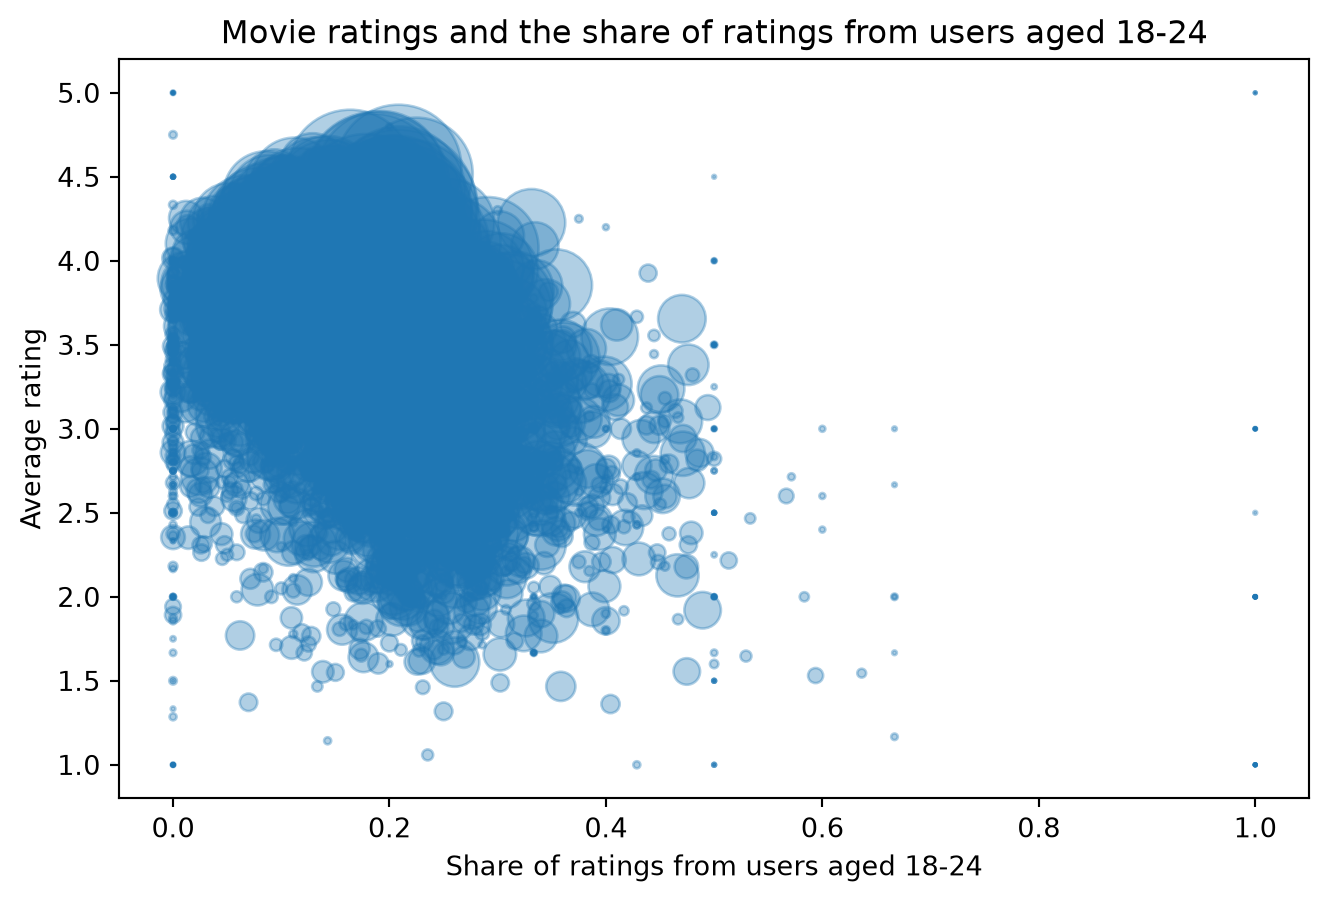

,movie_id,average_rating,share_age_18_24,number_of_ratings,title
0,1,4.146846,0.215696,2077,Toy Story (1995)
1,2,3.201141,0.219686,701,Jumanji (1995)
2,3,3.016736,0.223849,478,Grumpier Old Men (1995)
3,4,2.729412,0.229412,170,Waiting to Exhale (1995)
4,5,3.006757,0.219595,296,Father of the Bride Part II (1995)


In [5]:
ratings_with_age = ratings.merge(users[["user_id", "age"]], on="user_id")
movie_age_summary = (
    ratings_with_age.groupby("movie_id", as_index=False)
    .agg(
        average_rating=("rating", "mean"),
        share_age_18_24=("age", lambda ages: ages.eq(18).mean()),
        number_of_ratings=("rating", "size"),
    )
    .merge(movies[["movie_id", "title"]], on="movie_id", how="left")
)
import matplotlib.pyplot as plt
ax = movie_age_summary.plot.scatter(
    x="share_age_18_24",
    y="average_rating",
    s="number_of_ratings",
    alpha=0.35,
    figsize=(8, 5),
)
ax.set_xlabel("Share of ratings from users aged 18-24")
ax.set_ylabel("Average rating")
ax.set_title("Movie ratings and the share of ratings from users aged 18-24")
plt.show()
movie_age_summary.head()

5\. Calculate the number of ratings by movie. How many of the movies had zero ratings?

(_Hint_: Why is an inner join not sufficient here?)

In [6]:
movie_counts = (
    movies[["movie_id", "title"]]
    .merge(
        ratings.groupby("movie_id", as_index=False).size().rename(columns={"size": "number_of_ratings"}),
        on="movie_id",
        how="left",
    )
    .assign(number_of_ratings=lambda frame: frame["number_of_ratings"].fillna(0).astype(int))
)
zero_rated_movies = movie_counts[movie_counts["number_of_ratings"].eq(0)]
display(movie_counts.head())
pd.DataFrame({"movies_with_zero_ratings": [len(zero_rated_movies)]})

,movie_id,title,number_of_ratings
0,1,Toy Story (1995),2077
1,2,Jumanji (1995),701
2,3,Grumpier Old Men (1995),478
3,4,Waiting to Exhale (1995),170
4,5,Father of the Bride Part II (1995),296


,movies_with_zero_ratings
0,177


6\. How many movies received both a 1 and a 5 rating? Which movies? How many ratings of each type (1 or 5 stars)? Answer these question by joining two appropriate tables.

In [7]:
one_star_counts = (
    ratings[ratings["rating"].eq(1)]
    .groupby("movie_id", as_index=False)
    .agg(one_star_ratings=("rating", "size"))
)
five_star_counts = (
    ratings[ratings["rating"].eq(5)]
    .groupby("movie_id", as_index=False)
    .agg(five_star_ratings=("rating", "size"))
)
movies_with_both_ratings = (
    one_star_counts.merge(five_star_counts, on="movie_id", how="inner")
    .merge(movies[["movie_id", "title"]], on="movie_id", how="left")
    [["movie_id", "title", "one_star_ratings", "five_star_ratings"]]
    .sort_values("title")
)
display(pd.DataFrame({"movies_with_both_1_and_5_ratings": [len(movies_with_both_ratings)]}))
movies_with_both_ratings

,movies_with_both_1_and_5_ratings
0,2986


,movie_id,title,one_star_ratings,five_star_ratings
1472,2031,"$1,000,000 Duck (1971)",3,4
2353,3112,'Night Mother (1986),4,13
572,779,'Til There Was You (1997),5,2
1511,2072,"'burbs, The (1989)",36,23
2561,3420,...And Justice for All (1979),2,38
...,...,...,...,...
1600,2165,Your Friends and Neighbors (1998),9,17
2432,3223,"Zed & Two Noughts, A (1985)",2,3
1322,1845,Zero Effect (1998),7,82
1057,1426,Zeus and Roxanne (1997),5,1
